<a href="https://colab.research.google.com/github/tanujkochar26/Sentiment-Analysis/blob/main/News_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import nltk
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import random
from wordcloud import WordCloud
import os
import spacy
nlp = spacy.load('en_core_web_sm')
from textblob import TextBlob


In [2]:
!pip install pattern

In [5]:
import warnings

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=DeprecationWarning)

In [6]:
req=requests.get('https://www.newsy.com/stories/commercial-companies-advance-space-exploration/')
req.encoding = 'utf-8'

In [7]:
html = req.text

In [8]:
html

'<!DOCTYPE html>\n<html class="Page-body ArticlePage" lang="en">\n<head>\n    <script>\n        window.environment=\'production\';\n        window.callLetters=\'snews\';\n    </script>\n\n    <!-- Early Elements go here -->\n    <meta name="facebook-domain-verification" content="5fbrhv5h1jok6kv4yxx77u5vsrws6w" />\n\n\n    <link rel="dns-prefetch" href="https://securepubads.g.doubleclick.net">\n    <link rel="preconnect" href="https://securepubads.g.doubleclick.net">\n    <link rel="preconnect" href="https://securepubads.g.doubleclick.net" crossorigin>\n\n    <link rel="preload" href="https://assets.scrippsdigital.com/fontawesome/css/fontawesome.min.gz.css" as="style" onload="this.onload=null;this.rel=\'stylesheet\'">\n    <noscript><link rel="stylesheet" href="https://assets.scrippsdigital.com/fontawesome/css/fontawesome.min.gz.css"></noscript>\n    <link rel="preload" href="https://assets.scrippsdigital.com/fontawesome/css/brands.min.gz.css" as="style" onload="this.onload=null;this.re

In [9]:
soup = BeautifulSoup(html)
text = soup.get_text()

In [10]:
len(text)

6169

In [34]:
print(text[100:1100])
































































































































 Watch Now 






















        Menu
        


        U.S. News
    

        Politics
    

        Health
    

        World News
    

        Investigations
    

        Shows
    

        Watch Now
        







Watch Now 




Close ×


Live
Watch


 Alerts





Search site

Go









Watch Live






News




Business

Crime

Education

Entertainment

Good News

Health

Scripps News Life

Politics

Science and Tech

Sports

U.S. News

Weather

World News






Shows




TV Schedule

Morning Rush

The National Report

On the Scene

Happening Now in America

Today as it Happened

Scripps News Weekend

In The Shadows with Jason Bellini


The Week as it Happened 

Scripps News Showcase

More Shows






Documentaries






Next Level

Bellingcat

All Docs






Investigations




Scripps News Investigates

Poisoned: Fentanyl's Child Victims

In [12]:
clean_text= text.replace("\n", " ")
clean_text= clean_text.replace("/", " ")
clean_text= ''.join([c for c in clean_text if c != "'"])

In [13]:
clean_text=" ".join(clean_text.split())
clean_text

'Commercial Companies Advance Space Exploration (VIDEO) Watch Now Menu U.S. News Politics Health World News Investigations Shows Watch Now Watch Now Close × Live Watch Alerts Search site Go Watch Live News Business Crime Education Entertainment Good News Health Scripps News Life Politics Science and Tech Sports U.S. News Weather World News Shows TV Schedule Morning Rush The National Report On the Scene Happening Now in America Today as it Happened Scripps News Weekend In The Shadows with Jason Bellini The Week as it Happened Scripps News Showcase More Shows Documentaries Next Level Bellingcat All Docs Investigations Scripps News Investigates Poisoned: Fentanyls Child Victims Hope Denied Vacation Rentals: At Your Own Risk Maine Shooting Ukraines Women Warriors More Investigations Latest Videos About Scripps News News Team Viewer Hotline Download Our App Follow Us Facebook Instagram X TikTok YouTube Threads LinkedIn Newsletter Manage Emails Apps Careers Search scrippsnews scrippsnews scr

In [14]:
sentence=[]
tokens = nlp(clean_text)
for sent in tokens.sents:
    sentence.append((sent.text.strip()))

In [15]:
sentence

['Commercial Companies Advance Space Exploration (VIDEO)',
 'Watch Now',
 'Menu U.S. News Politics Health World News Investigations Shows Watch',
 'Now Watch Now Close × Live Watch Alerts Search site Go Watch Live News Business Crime Education Entertainment Good News Health Scripps News Life Politics Science and Tech Sports',
 'U.S. News Weather World News Shows TV Schedule Morning Rush',
 'The National Report On the Scene Happening Now in America Today as it Happened Scripps News Weekend',
 'In The Shadows with Jason Bellini The Week as it Happened Scripps News',
 'Showcase',
 'More Shows Documentaries Next Level Bellingcat All Docs Investigations Scripps News Investigates Poisoned: Fentanyls Child Victims Hope Denied Vacation Rentals:',
 'At Your Own Risk Maine Shooting Ukraines Women Warriors More Investigations Latest Videos About Scripps News News Team Viewer Hotline Download Our App Follow Us Facebook Instagram X TikTok YouTube Threads LinkedIn Newsletter Manage Emails Apps Caree

In [16]:
print(len(sentence))

41


In [17]:
textblob_sentiment=[]
for s in sentence:
    txt= TextBlob(s)
    a= txt.sentiment.polarity
    b= txt.sentiment.subjectivity
    textblob_sentiment.append([s,a,b])

In [18]:
df_textblob = pd.DataFrame(textblob_sentiment, columns =['Sentence', 'Polarity', 'Subjectivity'])

In [19]:
df_textblob.head()

,Sentence,Polarity,Subjectivity
0,Commercial Companies Advance Space Exploration...,0.000000,0.000000
1,Watch Now,0.000000,0.000000
2,Menu U.S. News Politics Health World News Inve...,0.000000,0.000000
3,Now Watch Now Close × Live Watch Alerts Search...,0.324242,0.533333
4,U.S. News Weather World News Shows TV Schedule...,0.000000,0.000000


In [20]:
df_textblob.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sentence      41 non-null     object 
 1   Polarity      41 non-null     float64
 2   Subjectivity  41 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.1+ KB


Text(0.5, 12.44444444444443, 'Sentence Polarity (Textblob)')

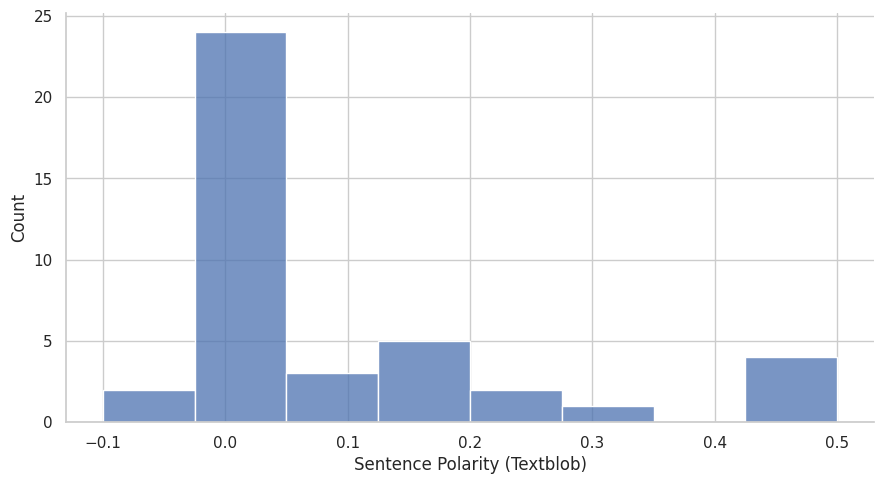

In [21]:
sns.displot(df_textblob["Polarity"], height= 5, aspect=1.8)
plt.xlabel("Sentence Polarity (Textblob)")


Text(0.5, 12.44444444444443, 'Sentence Subjectivity (Textblob)')

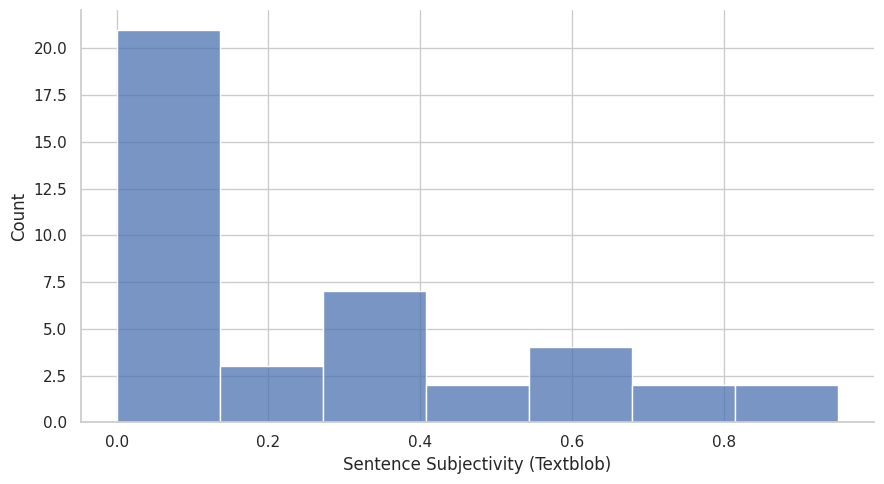

In [22]:
sns.displot(df_textblob["Subjectivity"], height= 5, aspect=1.8)
plt.xlabel("Sentence Subjectivity (Textblob)")

In [23]:
clean_text

'Commercial Companies Advance Space Exploration (VIDEO) Watch Now Menu U.S. News Politics Health World News Investigations Shows Watch Now Watch Now Close × Live Watch Alerts Search site Go Watch Live News Business Crime Education Entertainment Good News Health Scripps News Life Politics Science and Tech Sports U.S. News Weather World News Shows TV Schedule Morning Rush The National Report On the Scene Happening Now in America Today as it Happened Scripps News Weekend In The Shadows with Jason Bellini The Week as it Happened Scripps News Showcase More Shows Documentaries Next Level Bellingcat All Docs Investigations Scripps News Investigates Poisoned: Fentanyls Child Victims Hope Denied Vacation Rentals: At Your Own Risk Maine Shooting Ukraines Women Warriors More Investigations Latest Videos About Scripps News News Team Viewer Hotline Download Our App Follow Us Facebook Instagram X TikTok YouTube Threads LinkedIn Newsletter Manage Emails Apps Careers Search scrippsnews scrippsnews scr

In [24]:
tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+|\$[\d\.]+|\S+')

In [25]:
tokens = tokenizer.tokenize(clean_text)
len(tokens)

937

In [26]:
print(tokens)

['Commercial', 'Companies', 'Advance', 'Space', 'Exploration', '(VIDEO)', 'Watch', 'Now', 'Menu', 'U', '.S.', 'News', 'Politics', 'Health', 'World', 'News', 'Investigations', 'Shows', 'Watch', 'Now', 'Watch', 'Now', 'Close', '×', 'Live', 'Watch', 'Alerts', 'Search', 'site', 'Go', 'Watch', 'Live', 'News', 'Business', 'Crime', 'Education', 'Entertainment', 'Good', 'News', 'Health', 'Scripps', 'News', 'Life', 'Politics', 'Science', 'and', 'Tech', 'Sports', 'U', '.S.', 'News', 'Weather', 'World', 'News', 'Shows', 'TV', 'Schedule', 'Morning', 'Rush', 'The', 'National', 'Report', 'On', 'the', 'Scene', 'Happening', 'Now', 'in', 'America', 'Today', 'as', 'it', 'Happened', 'Scripps', 'News', 'Weekend', 'In', 'The', 'Shadows', 'with', 'Jason', 'Bellini', 'The', 'Week', 'as', 'it', 'Happened', 'Scripps', 'News', 'Showcase', 'More', 'Shows', 'Documentaries', 'Next', 'Level', 'Bellingcat', 'All', 'Docs', 'Investigations', 'Scripps', 'News', 'Investigates', 'Poisoned', ':', 'Fentanyls', 'Child', 'Vi

In [27]:
words = []
for word in tokens:
    words.append(word.lower())

In [28]:
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [29]:
stopwords[0:5]

['a', 'about', 'above', 'after', 'again']

In [30]:
words_new=[]
for word in words:
    if word not in stopwords:
        words_new.append(word)

In [31]:
len(words_new)

665

<Axes: xlabel='Samples', ylabel='Counts'>

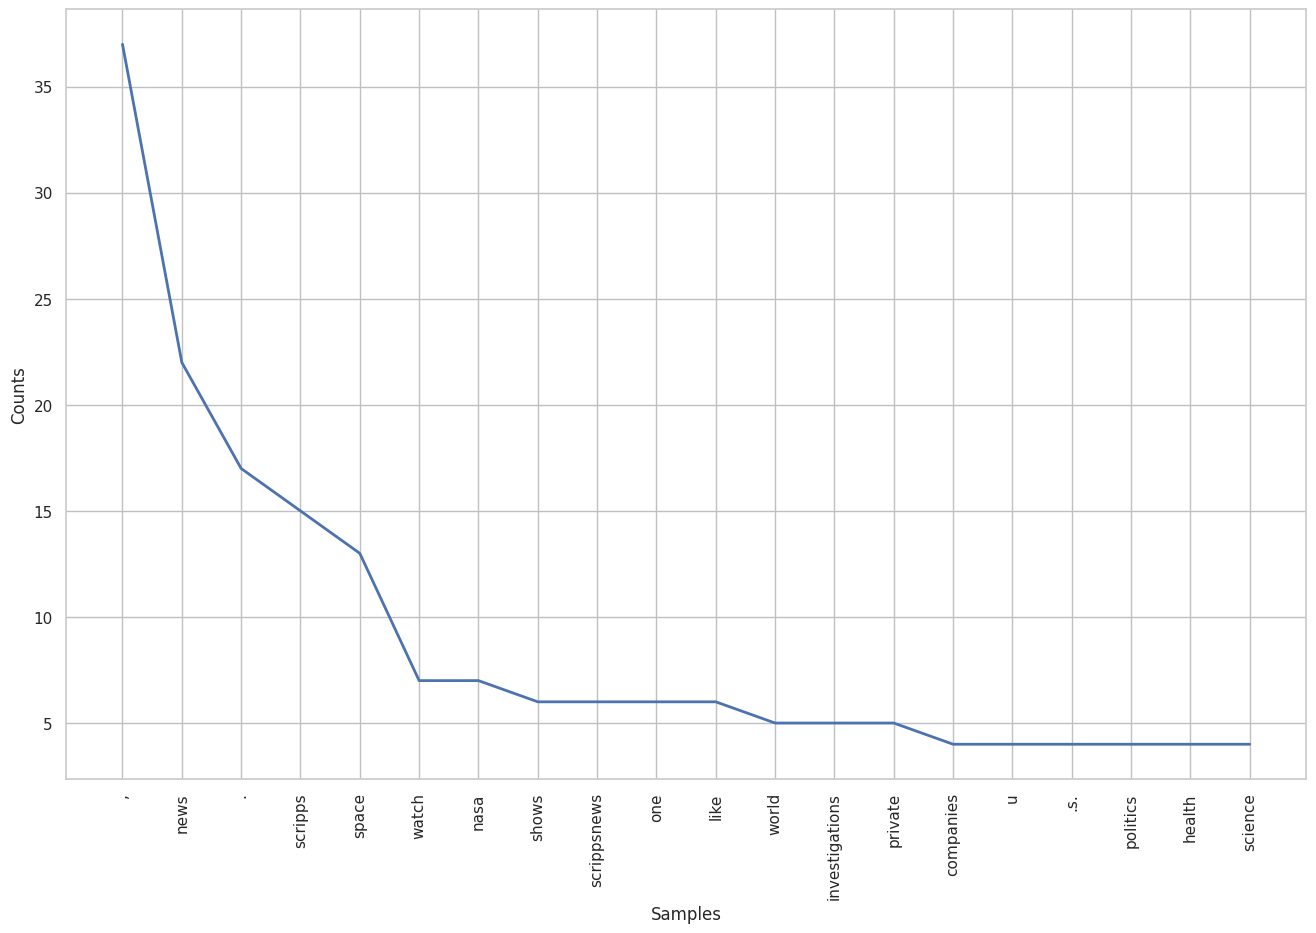

In [32]:
freq_dist = nltk.FreqDist(words_new)
plt.subplots(figsize=(16,10))
freq_dist.plot(20)

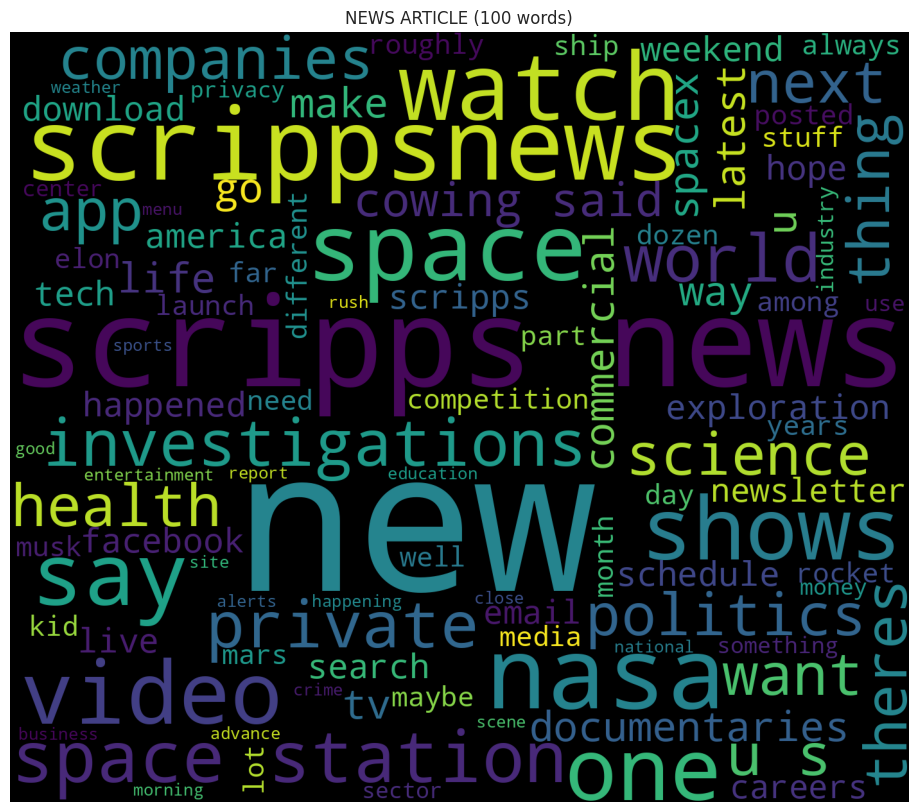

In [33]:
res=' '.join([i for i in words_new if not i.isdigit()])
plt.subplots(figsize=(16,10))
wordcloud = WordCloud(
                          background_color='black',
                          max_words=100,
                          width=1400,
                          height=1200
                         ).generate(res)
plt.imshow(wordcloud)
plt.title('NEWS ARTICLE (100 words)')
plt.axis('off')
plt.show()